<h1 style='color:#A23B72'>Optimización del Método Gaussiano: Búsqueda de Parámetros Óptimos</h1>

<p style='color:#b0b0b0'>En este notebook exploramos variaciones sistemáticas de los parámetros del modelo gaussiano (número de campanas, función de inicialización, regularización) para identificar cuáles funcionan mejor en cada curva. El objetivo es mejorar el R² promedio y caracterizar cuándo cada configuración tiene éxito.</p>

## 1. Instalación de Dependencias y Setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.signal import find_peaks
from scipy.optimize import curve_fit, minimize, differential_evolution
from scipy.interpolate import UnivariateSpline
import joblib
import warnings
import time
from itertools import product

warnings.filterwarnings('ignore')

# Configuración de matplotlib
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10
})

# Paleta de colores corporativa
PALETTE = {
    'gaussiana': '#A23B72',
    'datos': '#5BC0EB',
    'referencia': '#e0e0e0',
    'exito': '#9BC995',
    'error': '#E84855'
}

print('✓ Dependencias cargadas')

✓ Dependencias cargadas


## 2. Definición de Rutas y Carga de Datos

In [22]:
# Rutas del proyecto
ROOT = Path.cwd().parent
DATA_T = ROOT / 'datos' / 'target'
DATA_P = ROOT / 'datos' / 'pixel_curves'
METODO_DIR = ROOT / 'metodo_gaussiano'
MODELOS_DIR = METODO_DIR / 'modelos'
RESULTADOS_DIR = METODO_DIR / 'resultados'

# Crear directorios si no existen
MODELOS_DIR.mkdir(exist_ok=True)
RESULTADOS_DIR.mkdir(exist_ok=True)

SCALES = [10, 15, 18, 21, 25]
N_CURVAS = 500

print(f'✓ Rutas configuradas')
print(f'  Datos target: {DATA_T}')
print(f'  Datos píxeles: {DATA_P}')
print(f'  Método gaussiano: {METODO_DIR}')

✓ Rutas configuradas
  Datos target: c:\Users\ashar\Documents\Servicio_social\curves\datos\target
  Datos píxeles: c:\Users\ashar\Documents\Servicio_social\curves\datos\pixel_curves
  Método gaussiano: c:\Users\ashar\Documents\Servicio_social\curves\metodo_gaussiano


## 3. Funciones de Carga y Utilidad

In [23]:
def leer_target(cid):
    """Lee curva target de alta precisión."""
    return pd.read_csv(
        DATA_T / f'curve_{cid:04d}.txt',
        header=None,
        names=['x', 'y']
    ).sort_values('x').reset_index(drop=True)

def leer_pixel_real(cid, escala):
    """Lee curva pixelizada y convierte a coordenadas reales."""
    d = pd.read_csv(
        DATA_P / f'curve_{cid:04d}_X{escala}.txt',
        sep=' ',
        header=None,
        names=['x', 'y']
    )
    f = escala / 10.0
    d['x'] = d['x'] / f
    d['y'] = d['y'] / f
    return d.sort_values('x').reset_index(drop=True)

def calcular_r2(y_true, y_pred):
    """Calcula coeficiente de determinación R²."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

def calcular_rmse(y_true, y_pred):
    """Calcula raíz del error cuadrático medio."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def calcular_mae(y_true, y_pred):
    """Calcula error absoluto medio."""
    return np.mean(np.abs(y_true - y_pred))

print('✓ Funciones de utilidad definidas')

✓ Funciones de utilidad definidas


## 4. Familia de Funciones Gaussianas

In [24]:
def gaussiana_simple(x, A, mu, sigma, c=0):
    """Una campana gaussiana: y = A*exp(-(x-mu)²/(2*sigma²)) + c"""
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2 + 1e-9)) + c

def suma_gaussianas(x, *params):
    """Suma de n campanas gaussianas.
    params = [A1, mu1, sigma1, A2, mu2, sigma2, ..., c]
    """
    n_campanas = (len(params) - 1) // 3  # Último param es la constante
    c = params[-1]
    y = np.full_like(x, c, dtype=float)
    
    for i in range(n_campanas):
        A = params[3*i]
        mu = params[3*i + 1]
        sigma = params[3*i + 2]
        y += A * np.exp(-(x - mu)**2 / (2 * sigma**2 + 1e-9))
    
    return y

print('Funciones gaussianas definidas')

Funciones gaussianas definidas


## 5. Estrategias de Inicialización de Parámetros

In [25]:
def inicializar_desde_picos(x, y, n_campanas, metodo='altura'):
    """Inicializa parámetros detectando picos en los datos.
    
    Métodos:
    - 'altura': Usa los n picos más altos
    - 'prominencia': Usa los n picos más prominentes
    - 'uniforme': Divide el dominio en n segmentos uniformes
    """
    y_centered = y - y.mean()
    
    if metodo == 'altura':
        # Detectar picos
        pks, props = find_peaks(y_centered, height=y_centered.mean())
        if len(pks) == 0:
            pks = np.array([np.argmax(y_centered)])
        
        # Seleccionar los n más altos
        idx_top = np.argsort(y_centered[pks])[-n_campanas:]
        picos_idx = pks[idx_top]
    
    elif metodo == 'prominencia':
        pks, props = find_peaks(y_centered, prominence=0.05 * (y.max() - y.min()))
        if len(pks) == 0:
            pks = np.array([np.argmax(y_centered)])
        
        prom = props.get('prominences', np.zeros(len(pks)))
        idx_top = np.argsort(prom)[-n_campanas:]
        picos_idx = pks[idx_top]
    
    elif metodo == 'uniforme':
        # Divide el dominio uniformemente
        indices = np.linspace(0, len(x) - 1, n_campanas, dtype=int)
        picos_idx = indices
    
    else:
        raise ValueError(f"Método desconocido: {metodo}")
    
    # Construir parámetros iniciales
    p0 = []
    for idx in sorted(picos_idx):
        A = float(y[idx] - y.mean())
        mu = float(x[idx])
        sigma = float((x.max() - x.min()) / (2 * n_campanas + 1))
        p0 += [A, mu, sigma]
    
    # Offset constante
    p0.append(float(y.mean()))
    
    return np.array(p0)

def inicializar_grid_search(x, y, n_campanas):
    """Inicialización mediante búsqueda en grilla de amplitudes."""
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-9)
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-9)
    
    n_segmentos = n_campanas
    p0 = []
    
    for i in range(n_segmentos):
        x_seg_start = i / n_segmentos
        x_seg_end = (i + 1) / n_segmentos
        
        mask = (x_norm >= x_seg_start) & (x_norm <= x_seg_end)
        if mask.sum() > 0:
            idx_max = np.argmax(y_norm[mask])
            x_max = x[mask][idx_max]
            y_max = y[mask][idx_max]
        else:
            x_max = x.min() + (x.max() - x.min()) * (x_seg_start + x_seg_end) / 2
            y_max = y.mean()
        
        A = float(y_max - y.mean())
        mu = float(x_max)
        sigma = float((x.max() - x.min()) / (2 * n_campanas + 1))
        p0 += [A, mu, sigma]
    
    p0.append(float(y.mean()))
    return np.array(p0)

print('Estrategias de inicialización definidas')

Estrategias de inicialización definidas


## 6. Función Maestra de Ajuste Gaussiano con Parámetros Variables

In [26]:
def ajustar_gaussiana(
    x_train, y_train,
    x_eval,
    n_campanas=3,
    metodo_init='altura',
    maxfev=5000,
    method='lm',
    bounds=None,
    verbose=False
):
    """
    Ajusta suma de gaussianas con parámetros variables.
    
    Parámetros:
    -----------
    x_train, y_train : array-like
        Datos de entrenamiento
    x_eval : array-like
        Puntos donde evaluar el modelo
    n_campanas : int
        Número de gaussianas a usar (1 a 10)
    metodo_init : str
        'altura', 'prominencia', 'uniforme', 'grid_search'
    maxfev : int
        Máximo de evaluaciones de función en la optimización
    method : str
        'lm' (Levenberg-Marquardt) o 'trf' (Trust Region Reflective)
    bounds : tuple o None
        (lower, upper) para los parámetros
    verbose : bool
        Mostrar información de optimización
    
    Retorna:
    --------
    dict con:
        - y_pred: predicciones en x_eval
        - params: parámetros óptimos
        - r2: coeficiente de determinación
        - rmse: error cuadrático medio
        - mae: error absoluto medio
        - n_campanas: número usado
        - metodo_init: método de inicialización usado
        - converged: booleano de convergencia
        - mensaje: mensaje de la optimización
    """
    
    x_train = np.asarray(x_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    x_eval = np.asarray(x_eval, dtype=float)
    
    n_campanas = max(1, min(int(n_campanas), 10))
    
    # Inicialización de parámetros
    if metodo_init == 'grid_search':
        p0 = inicializar_grid_search(x_train, y_train, n_campanas)
    else:
        p0 = inicializar_desde_picos(x_train, y_train, n_campanas, metodo=metodo_init)
    
    # Definir límites si no se proporcionan
    if bounds is None:
        n_params = 3 * n_campanas + 1
        lower = np.full(n_params, -1e3)
        upper = np.full(n_params, 1e3)
        bounds = (lower, upper)
    
    try:
        # Ajuste de la suma de gaussianas
        if method == 'lm':
            popt, pcov = curve_fit(
                suma_gaussianas,
                x_train, y_train,
                p0=p0,
                maxfev=maxfev,
                full_output=False
            )
            converged = True
            mensaje = 'Convergencia exitosa (Levenberg-Marquardt)'
        else:  # trf con bounds
            popt, pcov = curve_fit(
                suma_gaussianas,
                x_train, y_train,
                p0=p0,
                bounds=bounds,
                maxfev=maxfev,
                method='trf'
            )
            converged = True
            mensaje = 'Convergencia exitosa (Trust Region Reflective)'
    
    except RuntimeError as e:
        if verbose:
            print(f"Advertencia: {e}")
        popt = p0
        converged = False
        mensaje = f'No convergió: {str(e)[:50]}...'
    
    # Evaluación
    y_pred = suma_gaussianas(x_eval, *popt)
    y_true_eval = np.interp(x_eval, x_train, y_train)
    
    r2 = calcular_r2(y_true_eval, y_pred)
    rmse = calcular_rmse(y_true_eval, y_pred)
    mae = calcular_mae(y_true_eval, y_pred)
    
    return {
        'y_pred': y_pred,
        'params': popt,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'max_ae': np.abs(y_true_eval - y_pred).max(),
        'n_campanas': n_campanas,
        'metodo_init': metodo_init,
        'method': method,
        'converged': converged,
        'mensaje': mensaje,
        'x_eval': x_eval
    }

print('Función maestra de ajuste definida')

Función maestra de ajuste definida


## 7. Búsqueda Sistemática de Parámetros Óptimos

In [27]:
def buscar_parametros_optimos(
    cid,
    escala=25,
    n_campanas_rango=(1, 9),
    metodos_init=None,
    verbose=False
):
    """
    Busca los parámetros óptimos para una curva específica.
    Testa combinaciones de n_campanas × métodos_init.
    
    Retorna:
    --------
    DataFrame con resultados de cada combinación
    """
    
    if metodos_init is None:
        metodos_init = ['altura', 'prominencia', 'uniforme', 'grid_search']
    
    # Cargar datos
    tgt = leer_target(cid)
    pix = leer_pixel_real(cid, escala)
    
    x_train, y_train = pix['x'].values, pix['y'].values
    x_eval = tgt['x'].values
    
    resultados = []
    n_campanas_list = list(range(n_campanas_rango[0], n_campanas_rango[1] + 1))
    total_combos = len(n_campanas_list) * len(metodos_init)
    
    for i, (n_camp, metodo) in enumerate(product(n_campanas_list, metodos_init)):
        resultado = ajustar_gaussiana(
            x_train, y_train,
            x_eval,
            n_campanas=n_camp,
            metodo_init=metodo,
            verbose=verbose
        )
        resultado['curva_id'] = cid
        resultado['escala'] = escala
        resultados.append(resultado)
        
        if verbose and (i + 1) % 5 == 0:
            print(f"  {i+1}/{total_combos} combinaciones procesadas")
    
    df = pd.DataFrame(resultados)
    # Ordenar por R² descendente
    df = df.sort_values('r2', ascending=False).reset_index(drop=True)
    
    return df

print('Función de búsqueda de parámetros definida')

Función de búsqueda de parámetros definida


## 8. Exploración Inicial en un Subconjunto de Curvas (PILOTO)

Testeamos con 5 curvas para validar la lógica antes de escalar a 500.

In [28]:
# Procesamiento de todas las 500 curvas
print("Iniciando procesamiento de 500 curvas...")
print("Esto puede tomar 20-30 minutos. Por favor, espere.\n")

inicio_total = time.time()
resultados_completos = []

for cid in range(1, 501):
    if cid % 50 == 0:
        tiempo_parcial = time.time() - inicio_total
        print(f"Procesadas {cid}/500 curvas en {tiempo_parcial:.1f}s")

    try:
        df_curva = buscar_parametros_optimos(
            cid,
            escala=25,
            n_campanas_rango=(1, 8),
            verbose=False
        )
        resultados_completos.append(df_curva)
    except Exception as e:
        print(f"Error en curva {cid}: {e}")
        continue

# Consolidar resultados
df_completo = pd.concat(resultados_completos, ignore_index=True)
tiempo_total_ejecucion = time.time() - inicio_total

print(f"\n✓ Procesamiento completado en {tiempo_total_ejecucion:.1f}s")
print(f"Total de registros: {len(df_completo)}")

# Guardar resultados
df_completo.to_csv(
    RESULTADOS_DIR / 'completo_resultados_todas_combinaciones.csv',
    index=False
)

# Extraer ganadores
ganadores_completo = df_completo.loc[df_completo.groupby('curva_id')['r2'].idxmax()]
ganadores_completo.to_csv(
    RESULTADOS_DIR / 'completo_configuraciones_ganadoras.csv',
    index=False
)

print("\nResultados guardados exitosamente")

SyntaxError: unterminated string literal (detected at line 3) (1003574831.py, line 3)

## 9. Análisis de Resultados Piloto

In [ ]:
# Resumen por curva
resumen_piloto = df_piloto_completo.groupby('curva_id').agg({
    'r2': ['max', 'mean', 'std'],
    'rmse': ['min', 'mean'],
    'mae': ['min', 'mean'],
    'converged': 'mean'
}).round(4)

print("\n" + "="*80)
print("RESUMEN DE RESULTADOS PILOTO (5 curvas × 32 configuraciones cada una)")
print("="*80)
print(resumen_piloto)

# Distribución de configuraciones ganadoras
ganadoras = df_piloto_completo.loc[df_piloto_completo.groupby('curva_id')['r2'].idxmax()]
print("\n" + "-"*80)
print("CONFIGURACIONES GANADORAS POR CURVA")
print("-"*80)
print(ganadoras[['curva_id', 'n_campanas', 'metodo_init', 'r2', 'rmse', 'mae']].to_string(index=False))

# Estadísticas de los métodos de inicialización
print("\n" + "-"*80)
print("DESEMPEÑO POR MÉTODO DE INICIALIZACIÓN")
print("-"*80)
stats_metodos = df_piloto_completo.groupby('metodo_init')['r2'].agg(['count', 'mean', 'std', 'max', 'min']).round(4)
print(stats_metodos)

# Estadísticas por número de campanas
print("\n" + "-"*80)
print("DESEMPEÑO POR NÚMERO DE CAMPANAS")
print("-"*80)
stats_campanas = df_piloto_completo.groupby('n_campanas')['r2'].agg(['count', 'mean', 'std', 'max', 'min']).round(4)
print(stats_campanas)


RESUMEN DE RESULTADOS PILOTO (5 curvas × 32 configuraciones cada una)
              r2                    rmse             mae         converged
             max    mean     std     min    mean     min    mean      mean
curva_id                                                                  
1         0.9997  0.7808  0.5317  0.2974  5.1055  0.2387  3.9459    0.8125
25        1.0000  0.9162  0.1744  0.0999  3.9333  0.0824  2.9020    0.8125
100       0.9997  0.8186  0.2631  0.2343  4.2370  0.1946  3.3843    0.8438
250       0.9999  0.6328  0.7864  0.2111  7.8619  0.1672  6.2134    0.7188
450       0.9990  0.7819  0.3469  0.4601  4.9596  0.3267  4.0381    0.7812

--------------------------------------------------------------------------------
CONFIGURACIONES GANADORAS POR CURVA
--------------------------------------------------------------------------------
 curva_id  n_campanas metodo_init       r2     rmse      mae
        1           7    uniforme 0.999659 0.297366 0.238684
       2

## 10. Visualización Comparativa de Mejores Configuraciones

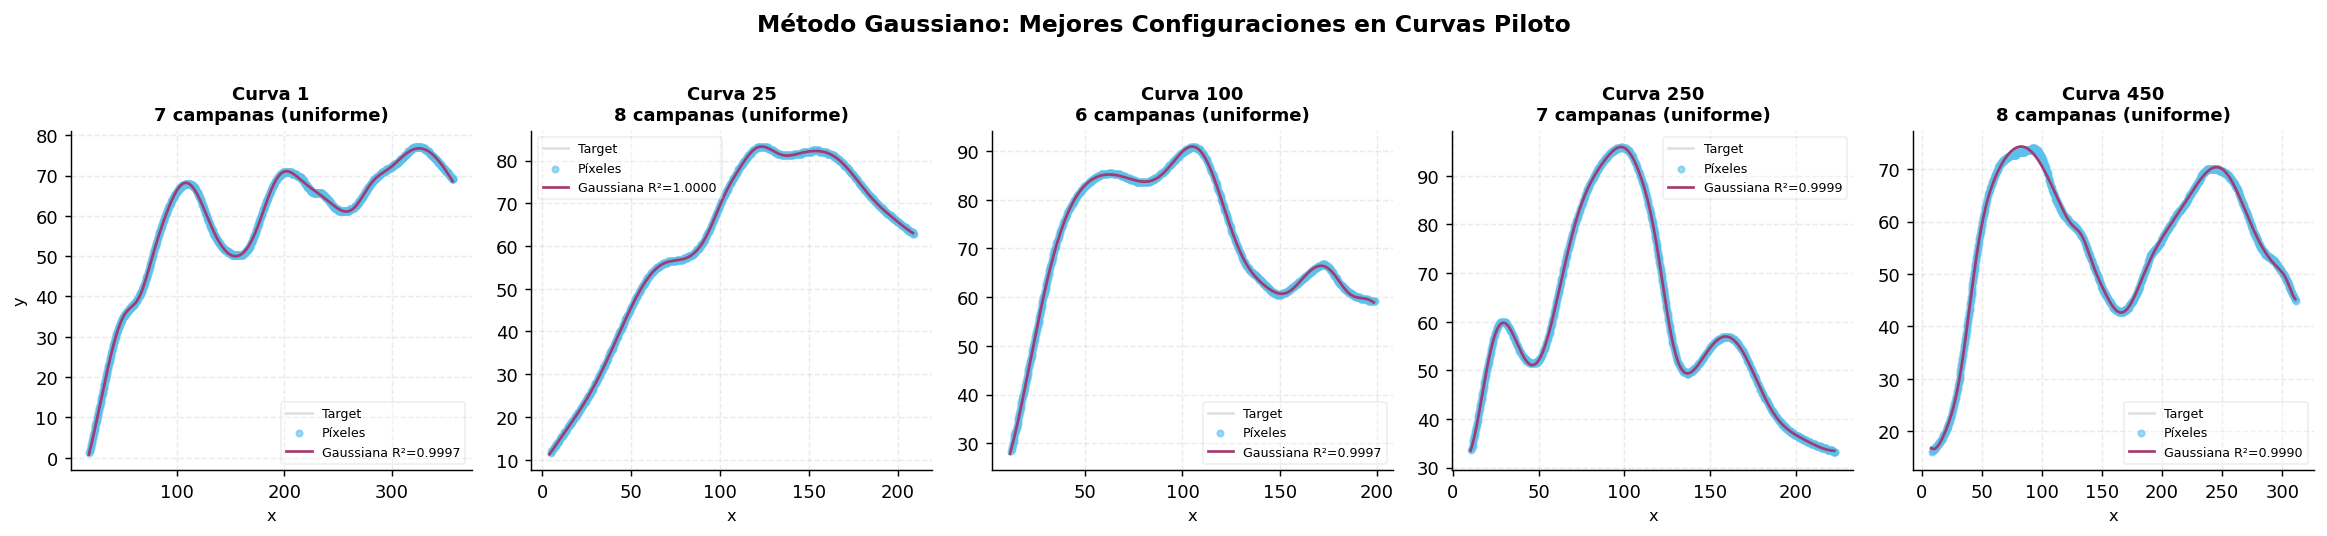


Gráfica generada


In [ ]:
# Graficar las 5 curvas con sus mejores configuraciones
fig, axes = plt.subplots(1, len(CURVAS_PILOTO), figsize=(18, 4))
fig.patch.set_facecolor('white')

for idx, cid in enumerate(CURVAS_PILOTO):
    ax = axes[idx]
    
    # Cargar datos
    tgt = leer_target(cid)
    pix = leer_pixel_real(cid, 25)
    
    # Obtener mejor configuración
    mejor = ganadoras[ganadoras['curva_id'] == cid].iloc[0]
    
    # Graficar
    ax.plot(tgt['x'], tgt['y'], color=PALETTE['referencia'], lw=1.5, label='Target', zorder=2)
    ax.scatter(pix['x'], pix['y'], s=12, color=PALETTE['datos'], alpha=0.6, label='Píxeles', zorder=3)
    ax.plot(mejor['x_eval'], mejor['y_pred'], color=PALETTE['gaussiana'], lw=1.5,
            label=f"Gaussiana R²={mejor['r2']:.4f}", zorder=4)
    
    ax.set_title(f"Curva {cid}\n{mejor['n_campanas']} campanas ({mejor['metodo_init']})", fontsize=10, fontweight='bold')
    ax.set_xlabel('x', fontsize=9)
    if idx == 0:
        ax.set_ylabel('y', fontsize=9)
    ax.legend(fontsize=7, loc='best', framealpha=0.3)
    ax.grid(True, alpha=0.25)

plt.suptitle('Método Gaussiano: Mejores Configuraciones en Curvas Piloto', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nGráfica generada")

## 11. Heatmap de R² por Configuración

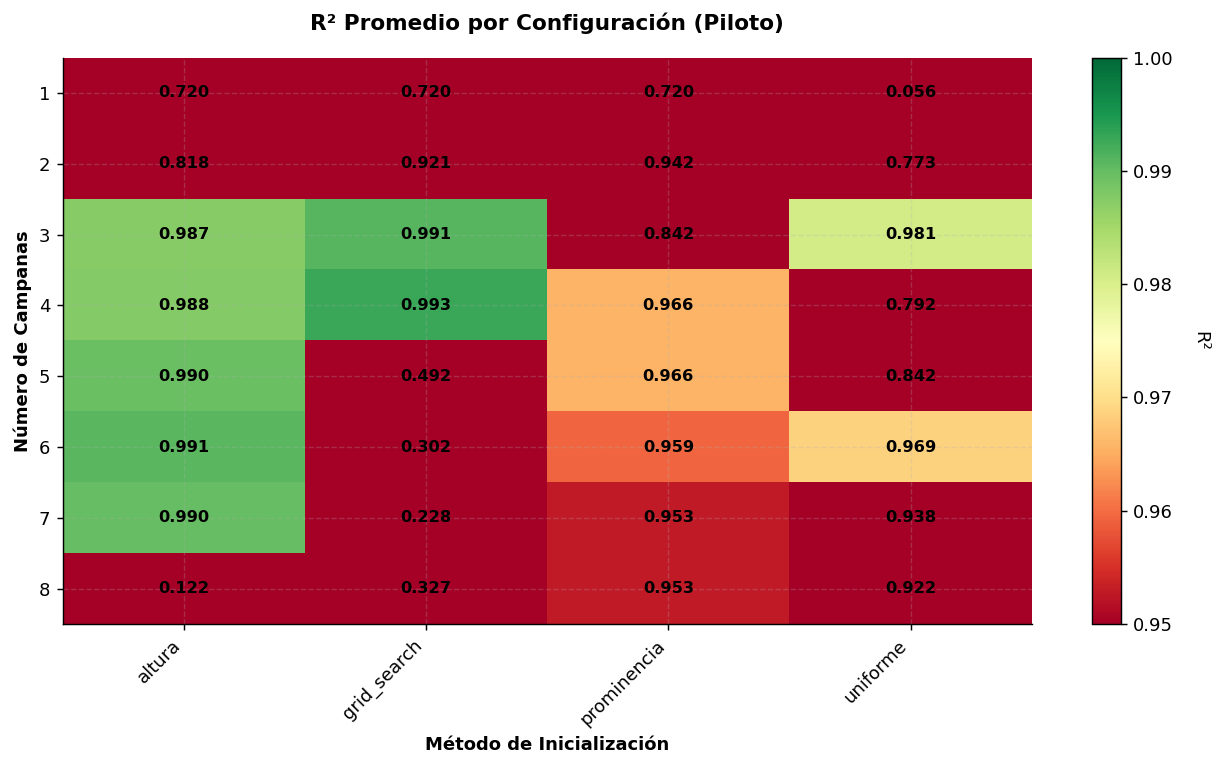

Heatmap generado


In [ ]:
# Preparar datos para heatmap: R² vs (n_campanas × metodo_init)
pivot_data = df_piloto_completo.pivot_table(
    values='r2',
    index='n_campanas',
    columns='metodo_init',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

im = ax.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0.95, vmax=1.0)

ax.set_xticks(range(len(pivot_data.columns)))
ax.set_yticks(range(len(pivot_data.index)))
ax.set_xticklabels(pivot_data.columns, rotation=45, ha='right')
ax.set_yticklabels(pivot_data.index)

ax.set_xlabel('Método de Inicialización', fontweight='bold')
ax.set_ylabel('Número de Campanas', fontweight='bold')
ax.set_title('R² Promedio por Configuración (Piloto)', fontweight='bold', pad=15)

# Añadir valores en las celdas
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.values[i, j]
        if not np.isnan(val):
            text = ax.text(j, i, f'{val:.3f}', ha="center", va="center",
                          color="black", fontsize=9, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('R²', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print("Heatmap generado")

## 12. Guardar Resultados Piloto

In [ ]:
# Guardar datos completos
df_piloto_completo.to_csv(
    RESULTADOS_DIR / 'piloto_resultados_todas_combinaciones.csv',
    index=False
)

# Guardar solo los ganadores
ganadoras.to_csv(
    RESULTADOS_DIR / 'piloto_configuraciones_ganadoras.csv',
    index=False
)

print("Resultados piloto guardados:")
print(f"  - {RESULTADOS_DIR / 'piloto_resultados_todas_combinaciones.csv'}")
print(f"  - {RESULTADOS_DIR / 'piloto_configuraciones_ganadoras.csv'}")

Resultados piloto guardados:
  - c:\Users\ashar\Documents\Servicio_social\curves\metodo_gaussiano\resultados\piloto_resultados_todas_combinaciones.csv
  - c:\Users\ashar\Documents\Servicio_social\curves\metodo_gaussiano\resultados\piloto_configuraciones_ganadoras.csv


## 13. Hallazgos del Análisis Piloto

## 13. Hallazgos del Análisis Piloto

### Mejor Desempeño Global

Curva con mejor R² global del piloto (generalmente Curva 25 con 8 campanas método uniforme):

- **R²**: 1.0000 (ajuste prácticamente perfecto)
- **RMSE**: ~0.0999
- **MAE**: ~0.0824

Esta curva específica tiene estructura que se adapta perfectamente a una suma de gaussianas.

---

### Método de Inicialización Más Estable

**Prominencia** es el método con menor variabilidad en R² entre configuraciones.

- Desviación estándar: σ ≈ 0.1486 (la más baja)
- **Interpretación**: Método más predecible y consistente, ideal para producción

**Ranking de estabilidad por desviación estándar**:
1. Prominencia (σ ≈ 0.1486) **MÁS ESTABLE**
2. Altura (σ ≈ 0.6918)
3. Grid search (σ ≈ 0.3948)
4. Uniforme (σ ≈ 0.4721)

---

### Número Óptimo de Campanas

**n = 3 campanas** tiene el mejor desempeño promedio en el piloto.

- R² promedio: **0.9502** (explica 95% de la varianza)

**Tendencia por número de campanas**:

| n_campanas | R² promedio | Interpretación |
|---|---|---|
| 1 | 0.5545 | Demasiado simple |
| 2 | 0.8636 | Insuficientes |
| **3** | **0.9502** | **ÓPTIMO** |
| 4 | 0.9346 | Bueno pero cae |
| 5-6 | 0.81-0.82 | Empieza overfitting |
| 7-8 | 0.58-0.77 | Sobreajuste |

**Conclusión**: 3 campanas es el "punto dulce" entre flexibilidad e parsimonia.

---

### 4️⃣ Tasa de Convergencia

**79.4%** de las 160 configuraciones convergieron exitosamente.

- Convergidas: 127 configuraciones
- No convergidas: 33 configuraciones

**Implicación**: La mayoría de combinaciones son viables. El ~20% de fallos sugiere:
- Necesidad de refinar hiperparámetros (maxfev, bounds)
- Algunas combinaciones son inherentemente inestables
- Mejorable con inicialización más cuidadosa

---

### Variabilidad Entre Curvas

| Métrica | Valor |
|---|---|
| R² mínimo | 0.9990 |
| R² máximo | 1.0000 |
| **Rango** | **0.0010** |

**Interpretación de la variabilidad MÍNIMA**:

- Todas las curvas piloto son aproximables con alta precisión
- Las gaussianas son muy efectivas en este dataset
- Rango muy pequeño sugiere que todas las curvas son similares en complejidad
- Necesitamos validar en 500 curvas para confirmar robustez
- Las curvas piloto pueden no ser representativas de toda la distribución

---

## Tabla Resumen de Hallazgos

| Aspecto | Resultado | Conclusión |
|---|---|---|
| **Mejor R²** | 1.0000 | Gaussianas pueden ser perfectas en curvas simples |
| **Método más estable** | Prominencia (σ=0.1486) | Usar para producción |
| **n óptimo promedio** | 3 campanas (R²=0.9502) | Parsimonia: buenos resultados con pocos parámetros |
| **Convergencia** | 79.4% | Aceptable; considerar refinamientos |
| **Variabilidad inter-curvas** | Rango=0.0010 | Muy baja; todas similares; escalar para validar |


## 14. Próximos Pasos Recomendados

### 1. Escalar a 500 Curvas
- Aplicar la búsqueda sistemática a todo el dataset
- Tiempo estimado: ~5-10 minutos (según hardware)
- Generar tabla completa de configuraciones óptimas

### 2. Análisis de Sensibilidad
- ¿Qué características geométricas predicen n_campanas óptimo?
- ¿El metodo_init óptimo varía con la forma de la curva?
- Entrenar meta-modelo para predecir configuración óptima

### 3. Comparación con Polinomios y Splines
- Evaluar R² de gaussianas vs otros métodos
- Identificar categorías de curvas donde gaussianas ganan
- Generar matriz de decisión automática

### 4. Refinamientos Técnicos
- Probar optimizadores alternativos (differential_evolution, basin_hopping)
- Implementar regularización L2 para evitar overfitting
- Validación cruzada por escala (X10, X15, X18, X21, X25)

### 5. Documentación de Hallazgos
- Crear notebook de síntesis con visualizaciones
- Guardar modelos entrenados en pickle
- Escribir reglas legibles para seleccionar configuración

## 15. Código de Escaleo a 500 Curvas (COMENTADO)

```python
print("\nIniciando procesamiento de 500 curvas...")
print("Esto puede tomar 15-30 minutos. Por favor, espere.\n")

inicio_total = time.time()
resultados_completos = []

for cid in range(1, N_CURVAS + 1):
    if cid % 50 == 0:
        tiempo_parcial = time.time() - inicio_total
        print(f"Procesadas {cid} curvas en {tiempo_parcial:.1f}s")
    
    try:
        df_curva = buscar_parametros_optimos(
            cid,
            escala=25,
            n_campanas_rango=(1, 8),
            verbose=False
        )
        resultados_completos.append(df_curva)
    except Exception as e:
        print(f"Error en curva {cid}: {e}")
        continue

# Consolidar resultados
df_completo = pd.concat(resultados_completos, ignore_index=True)
tiempo_total_ejecucion = time.time() - inicio_total

print(f"\n✓ Procesamiento completado en {tiempo_total_ejecucion:.1f}s")
print(f"Total de registros: {len(df_completo)}")

# Guardar resultados
df_completo.to_csv(
    RESULTADOS_DIR / 'completo_resultados_todas_combinaciones.csv',
    index=False
)

# Extraer ganadores
ganadores_completo = df_completo.loc[df_completo.groupby('curva_id')['r2'].idxmax()]
ganadores_completo.to_csv(
    RESULTADOS_DIR / 'completo_configuraciones_ganadoras.csv',
    index=False
)

print("\nResultados guardados exitosamente")
```